In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Plant_Disease_Project.zip'
extract_path = '/content/dataset'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(" Extraction complete .")
else:
    print("Error: Zip file nahi not found. ")

 Extraction complete .



**IMPORT LIBRARIES**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import cv2
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import os

** DATASET PATHS**


In [ ]:
train_path = "/content/dataset/Plant_Disease_Project/train"
val_path   = "/content/dataset/Plant_Disease_Project/val"
test_path  = "/content/dataset/Plant_Disease_Project/test"

**DATA PREPROCESSING + AUGMENTATION**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

**LOAD DATASET**

In [ ]:

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 2. Training Data
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 3. Validation Data
val_data = datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 4. Test Data
test_data = datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 6018 images belonging to 4 classes.
Found 1503 images belonging to 4 classes.
Found 7521 images belonging to 4 classes.


**DISPLAY CLASS NAMES**

In [ ]:
print("Class Names:")
print(train_data.class_indices)

Class Names:
{'Potato___healthy': 0, 'Tomato___Early_blight': 1, 'Tomato___Late_blight': 2, 'Tomato___healthy': 3}


** LOAD VGG16 MODEL (TRANSFER LEARNING)**

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**BUILD MODEL**

In [ ]:
model = models.Sequential([

    base_model,

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')

])

**COMPILE MODEL**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


**MODEL SUMMARY**


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

**EARLY STOPPING**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**TRAIN MODEL**


In [ ]:
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Explicitly build the model after re-definition
# (None for batch size, 224, 224 for image size, 3 for channels)
model.build(input_shape=(None, 224, 224, 3))

In [ ]:
# Training start
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 68s 285ms/step - accuracy: 0.8089 - loss: 0.5592 - val_accuracy: 0.9148 - val_loss: 0.2227
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 40s 213ms/step - accuracy: 0.9086 - loss: 0.2236 - val_accuracy: 0.9188 - val_loss: 0.2030
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 229ms/step - accuracy: 0.9207 - loss: 0.2020 - val_accuracy: 0.9148 - val_loss: 0.1947
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.9271 - loss: 0.1904 - val_accuracy: 0.9268 - val_loss: 0.1774
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 227ms/step - accuracy: 0.9384 - loss: 0.1518 - val_accuracy: 0.9401 - val_loss: 0.1581
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.9480 - loss: 0.1441 - val_accuracy: 0.9355 - val_loss: 0.1684
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.9166 - loss: 0.1885 - val_accuracy: 0.9281 - val_loss: 0.1718
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.9362 - loss: 0

**SAVE MODEl**

In [ ]:
model.save("plant_disease_model.h5")

print("Model Saved Successfully!")


Model Saved Successfully!


**ACCURACY GRAPH**

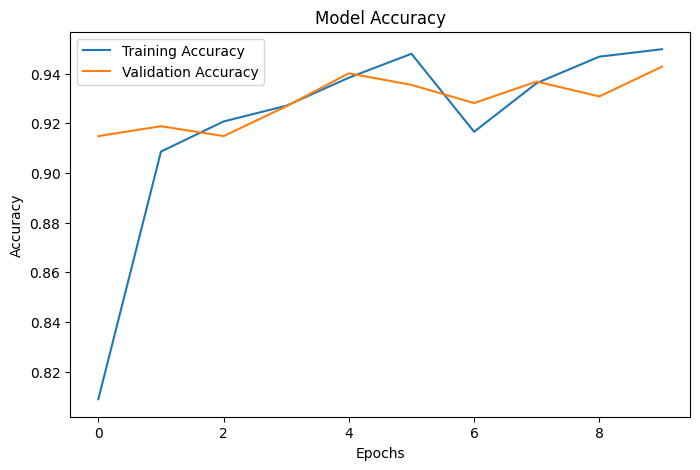

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

**LOSS GRAPH**

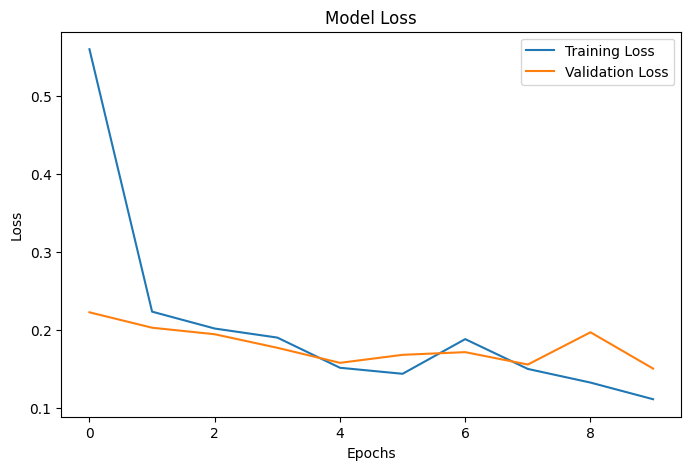

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

**EVALUATE MODEL**

In [ ]:
loss, accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")


236/236 ━━━━━━━━━━━━━━━━━━━━ 44s 188ms/step - accuracy: 0.9843 - loss: 0.0487

Test Accuracy: 98.43%


**PREDICTIONS**

In [ ]:
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

236/236 ━━━━━━━━━━━━━━━━━━━━ 45s 186ms/step


**CONFUSION MATRIX**

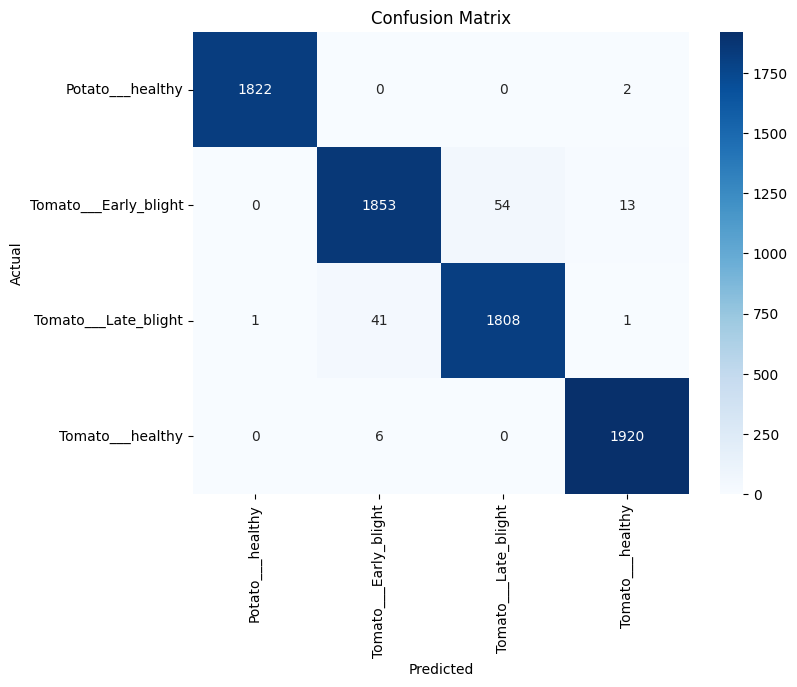

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**CLASSIFICATION REPORT**


In [ ]:
print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))



Classification Report:

                       precision    recall  f1-score   support

     Potato___healthy       1.00      1.00      1.00      1824
Tomato___Early_blight       0.98      0.97      0.97      1920
 Tomato___Late_blight       0.97      0.98      0.97      1851
     Tomato___healthy       0.99      1.00      0.99      1926

             accuracy                           0.98      7521
            macro avg       0.98      0.98      0.98      7521
         weighted avg       0.98      0.98      0.98      7521



**SINGLE IMAGE PREDICTION FUNCTION**

In [ ]:
def predict_image(img_path):

    img = tf.keras.utils.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    prediction = model.predict(img_array)

    predicted_class = class_labels[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    plt.imshow(img)

    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")

    plt.axis('off')

    plt.show()

    return predicted_class

**TEST SINGLE IMAGE**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step


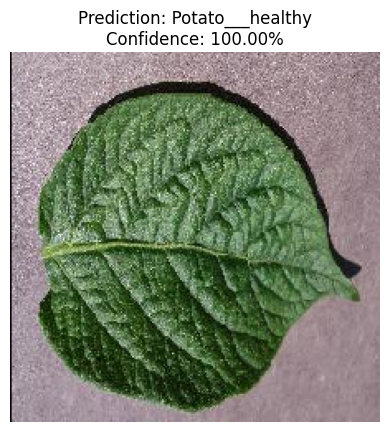

'Potato___healthy'

In [ ]:
import os

img_to_predict_path = os.path.join(
    test_path,
    'Potato___healthy',
    '00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864_270deg.JPG'
)

predict_image(img_to_predict_path)

**Grad-CAM Inspired Disease Region Visualization**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def simple_heatmap(img_path):

    # Read image
    img = cv2.imread(img_path)

    img = cv2.resize(img, (224,224))

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply heatmap
    heatmap = cv2.applyColorMap(gray, cv2.COLORMAP_JET)

    # Overlay heatmap
    output = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Show original image
    plt.figure(figsize=(6,6))

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.title("Original Image")

    plt.axis("off")

    plt.show()

    # Show heatmap image
    plt.figure(figsize=(6,6))

    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

    plt.title("Disease Region Visualization")

    plt.axis("off")

    plt.show()

**TEST**

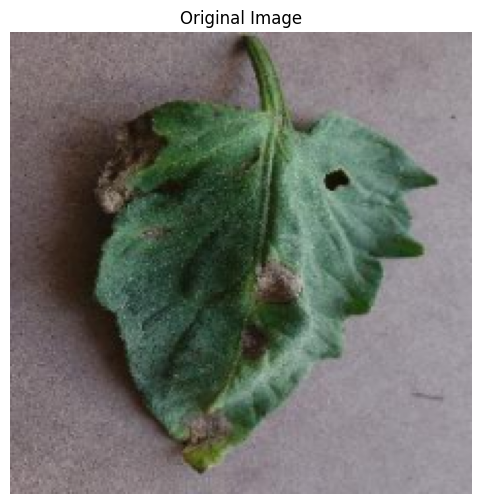

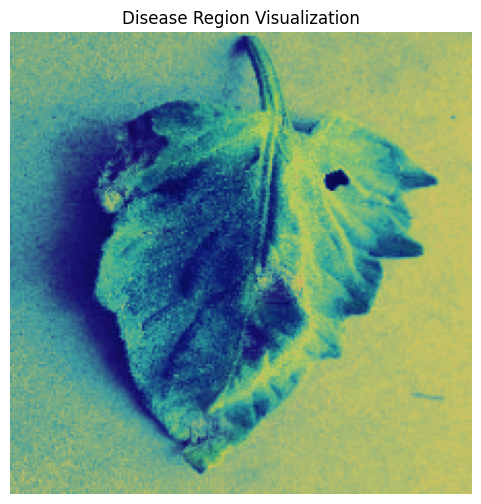

In [ ]:
test_path = "/content/dataset/Plant_Disease_Project/test/Tomato___Early_blight/0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly.B 7437_180deg.JPG"

simple_heatmap(test_path)

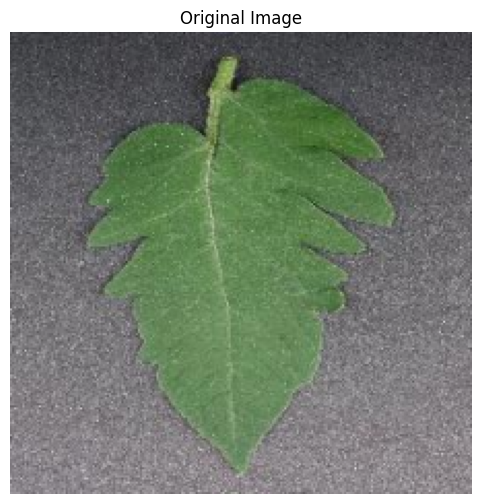

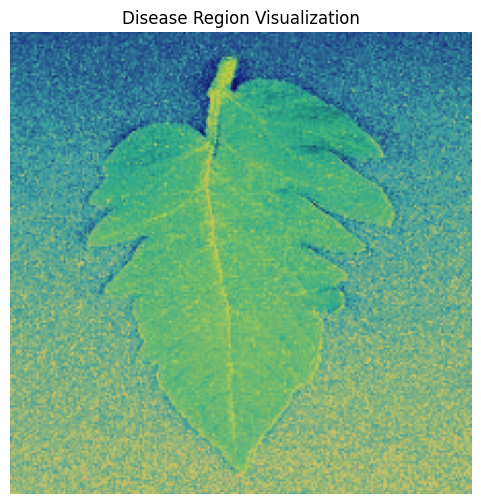

In [ ]:
test_path = "/content/dataset/Plant_Disease_Project/test/Tomato___healthy/000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1_180deg.JPG"

simple_heatmap(test_path)